In [1]:
import numpy as np
import yfinance as fy
import QuantLib as ql
from typing import Optional, Union
import pandas as pd
import matplotlib.pyplot as plt
import mocaxpy
from tqdm import tqdm
import seaborn as sb
import warnings
warnings.filterwarnings("ignore")
import multiprocess

from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.utils import timer
from inception.quantlib_python import date_to_date
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote

In [2]:
from pandas_datareader import data as pdr

import yfinance as yf
yf.pdr_override() # <== that's all it takes :-)

# download dataframe
data_dia = pdr.get_data_yahoo("DIA", start="2014-01-01", end="2024-03-01")
data_spy = pdr.get_data_yahoo("SPY", start="2014-01-01", end="2024-03-01")
data_xlv = pdr.get_data_yahoo("XLV", start="2014-01-01", end="2024-03-01")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:
log_return = np.c_[np.diff(np.log(data_dia.Close)), np.diff(np.log(data_spy.Close)), np.diff(np.log(data_xlv.Close))]
log_df = pd.DataFrame(log_return)
log_df['label'] = [i // 22 for i in log_df.index]
corr_matrix = np.corrcoef(log_df.groupby('label').sum().T)

In [4]:
corr_matrix 

array([[1.        , 0.96432854, 0.80799003],
       [0.96432854, 1.        , 0.8267037 ],
       [0.80799003, 0.8267037 , 1.        ]])

In [6]:
def autocallable_note_pricer(x: list, additonal_data = None):
    """
    The Autocallable Notes pricer function wrapper, (adapts the original function signature to the signature expected by MoCaX)
    :param x: [stock A price, stock B price, stock C price, days after the start date]
    :param additional_data: extra parameters required by MoCaX
    """
    start_date = '2024-02-14'
    # Input parameters:
    spot_price = np.array(x[:3])
    eval_date = pd.Timestamp(start_date) + pd.Timedelta(days=x[3])
    
    corr_matrix = np.array(
        [[1.        , 0.96432854, 0.80799003],
        [0.96432854, 1.        , 0.8267037 ],
        [0.80799003, 0.8267037 , 1.        ]]
    )
    issued_price = [382.82, 494.08, 142.86]
    index_vol = [0.16, 0.16, 0.16]
    risk_free_rate = 0.05
    path_num = 100_000
    d_s = 0.02
    parameters = NOTES_PARAMETERS['CIBC Multi Assets One']
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, spot_price, risk_free_rate, index_vol, corr_matrix, d_s)
    notes = MultiAssetAutoCallableNote(eval_date,
                                       ['A', 'B', 'C'],
                                       simulator, 
                                       parameters['valuation dates'],
                                       parameters['coupon dates'],
                                       parameters['call dates'],
                                       coupon_barrier=parameters['coupon barrier'],
                                       call_barrier=parameters['call barrier'],
                                       principal_barrier=parameters['principal barrier'],
                                       coupon_amount=parameters['coupon amount'],
                                       free_rate=risk_free_rate,
                                       n_paths=path_num)

    
    return notes.value

In [7]:
autocallable_note_pricer([382.82, 494.08, 142.86, 0])

101.71399956456426

In [14]:
# Deserialize the object to a file.
option_mocax = mocaxpy.Mocax.deserialize("./chebyshev_database/autocallable_notes_period_1.mcx")
value_id = option_mocax.get_derivative_id([0, 0, 0, 0])
delta_a = option_mocax.get_derivative_id([1, 0, 0, 0])
gamma_a = option_mocax.get_derivative_id([2, 0, 0, 0])
delta_b = option_mocax.get_derivative_id([0, 1, 0, 0])
gamma_b = option_mocax.get_derivative_id([0, 2, 0, 0])
delta_c = option_mocax.get_derivative_id([0, 0, 1, 0])
gamma_c = option_mocax.get_derivative_id([0, 0, 2, 0])

x = [382.82, 494.08, 142.86, 0]
print(autocallable_note_pricer(x))
import time

t1 = time.time()
for _ in range(1000):
    a = option_mocax.eval(x, value_id)
    
print((time.time() - t1)/1000)
print(option_mocax.eval(x, value_id))

101.74804324687292
0.00017023825645446776
109.09217681576331


In [15]:
import mocaxextendpy.mocax_extend as me

In [16]:
mocax_extend = me.MocaxExtend.deserialize("./chebyshev_database/autocallable_tensor_extension_0.pickle")

In [17]:
issued_price = [382.82, 494.08, 142.86]
calc_dates = np.arange(0, 91, 3)

price_percentage = np.arange(0.5, 1.3, 0.05)
values_mocax = []
values_func = []
for i, p in tqdm(enumerate(price_percentage)):
    values_mocax.append([])
    values_func.append([])
    for d in calc_dates:
        x = [price * p for price in issued_price] + [d]
#         values_mocax[i].append(option_mocax.eval(x, value_id))
        values_mocax[i].append(mocax_extend.cheb_tensor_evals(np.array([x]))[0])
        values_func[i].append(autocallable_note_pricer(x))


16it [13:38, 51.16s/it]


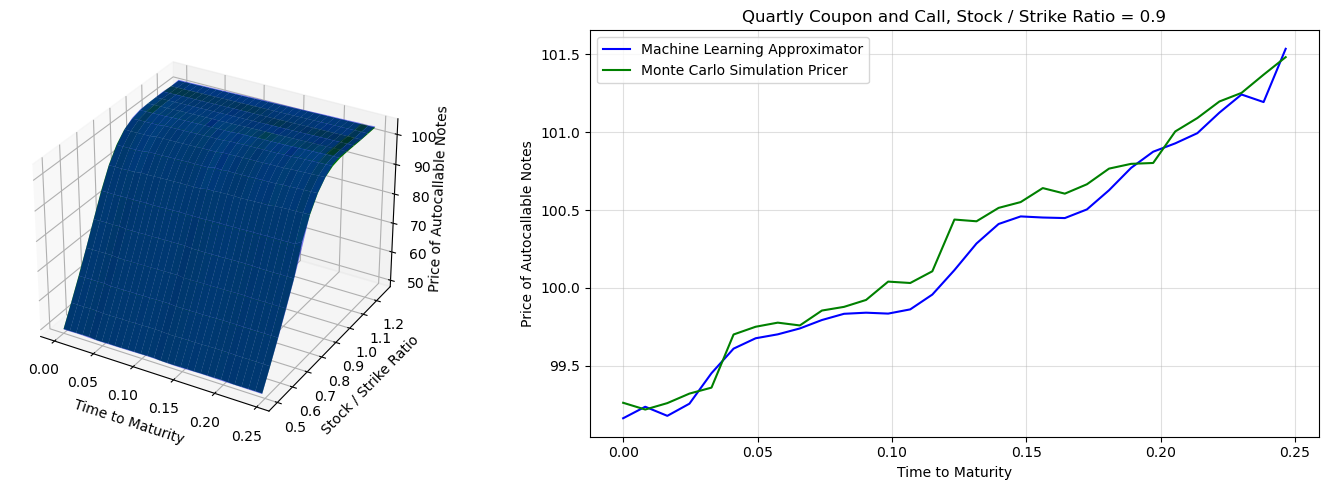

In [33]:
fig = plt.figure(figsize =(15, 5))

plt.subplot(121)
# ax = plt.axes(projection ='3d')
ax = plt.subplot(121, projection='3d')

times = [d / 365 for d in calc_dates]

x1,y1= np.meshgrid(times, price_percentage)

ax.plot_surface(x1, y1, np.array(values_mocax), color='blue', alpha=0.5)

ax.plot_surface(x1, y1, np.array(values_func), color='green')

ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Price of Autocallable Notes', rotation=90)
ax.zaxis.labelpad=-0.7

ax2 = plt.subplot(122)
ax2.plot(times, values_mocax[8], label='Machine Learning Approximator', color='blue')
ax2.plot(times, values_func[8], label='Monte Carlo Simulation Pricer', color='green')
ax2.grid(alpha=0.4)
ax2.set_xlabel('Time to Maturity')
ax2.set_ylabel('Price of Autocallable Notes')
ax2.legend()
ax2.set_title('Quartly Coupon and Call, Stock / Strike Ratio = 0.9')
plt.tight_layout();

Text(0.5, 0, 'Error (%)')

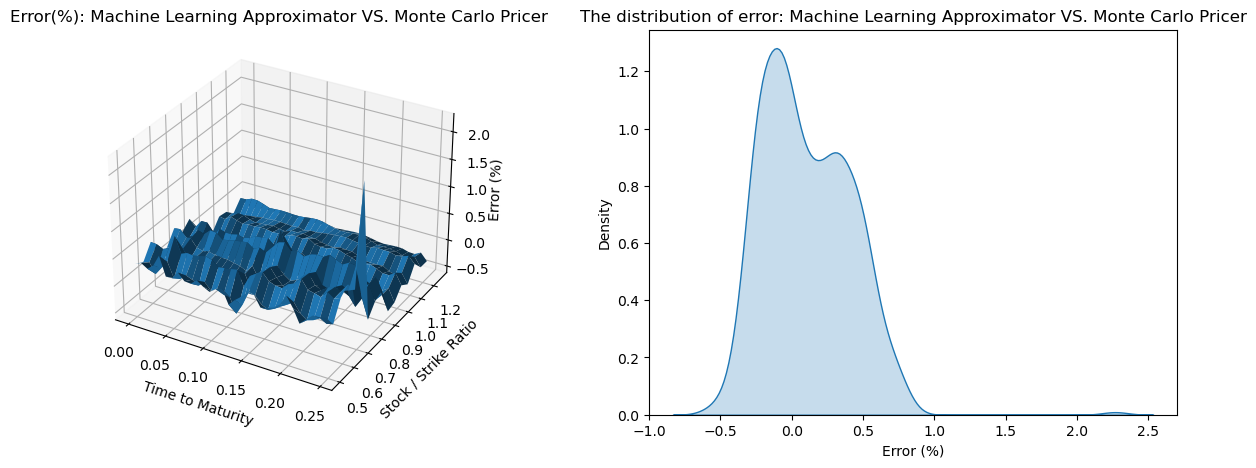

In [37]:
fig = plt.figure(figsize =(15, 5))

plt.subplot(121)
# ax = plt.axes(projection ='3d')
ax = plt.subplot(121, projection='3d')

times = [d / 365 for d in calc_dates]

x1,y1= np.meshgrid(times, price_percentage)
error = (np.array(values_func) - np.array(values_mocax)) / np.array(values_func) * 100

ax.plot_surface(x1, y1, error)
ax.set_title('Error(%): Machine Learning Approximator VS. Monte Carlo Pricer')


ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Error (%)', rotation=90)
ax.zaxis.labelpad=-0.7

ax2 = plt.subplot(122)
sb.kdeplot(error.flatten(),fill=True)
plt.title('The distribution of error: Machine Learning Approximator VS. Monte Carlo Pricer')
plt.xlabel('Error (%)')

In [13]:
func = lambda x: np.random.uniform(x * 0.5, x * 1.3)
value_m = []
value_p = []

for _ in range(100):
    x = [func(d) for d in issued_price] + [np.random.choice(np.arange(0, 91))]
    value_m.append(option_mocax.eval(x, value_id))
    value_p.append(autocallable_note_pricer(x))

Text(0.5, 0, 'The error of Chebyshev (%)')

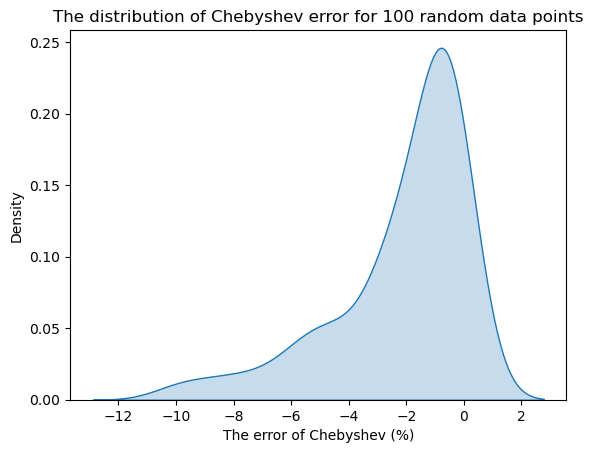

In [14]:
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('The distribution of Chebyshev error for 100 random data points')
plt.xlabel('The error of Chebyshev (%)')